Dataset Shape: (1143, 13)
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9

/tmp/ipykernel_3055/3688349822.py:28: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




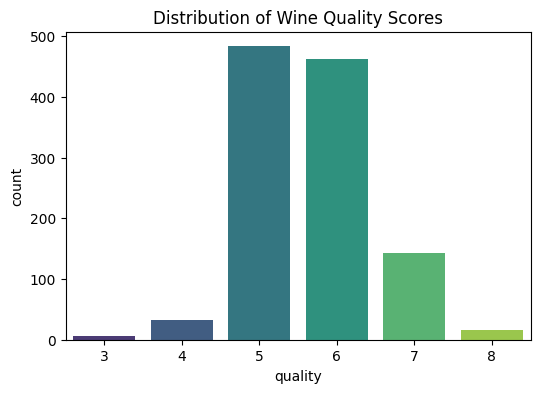

Explanation: This bar chart shows how many wines fall into each quality score. Most wines are rated 5–6, so the dataset is imbalanced.

Histograms for key features:


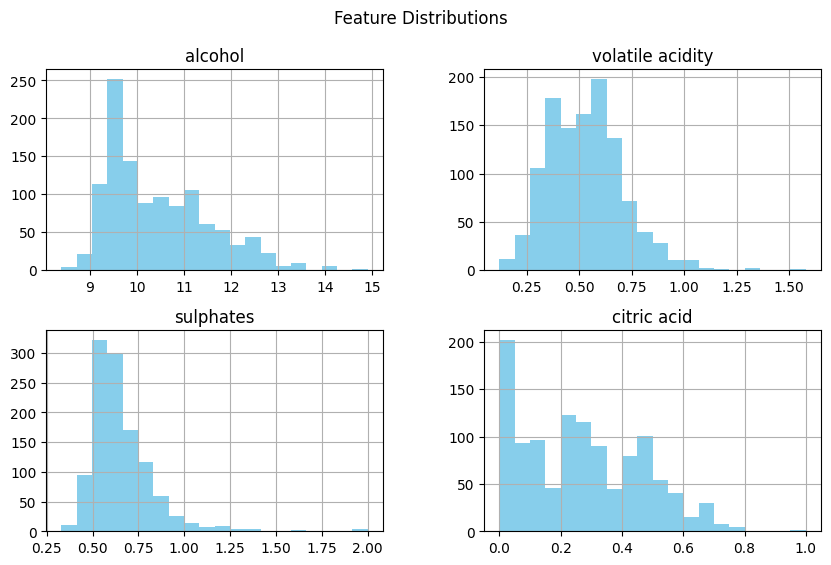

Explanation: These histograms show how chemical properties are distributed. Alcohol is mostly between 9–11%, volatile acidity is skewed lower.

Correlation heatmap:


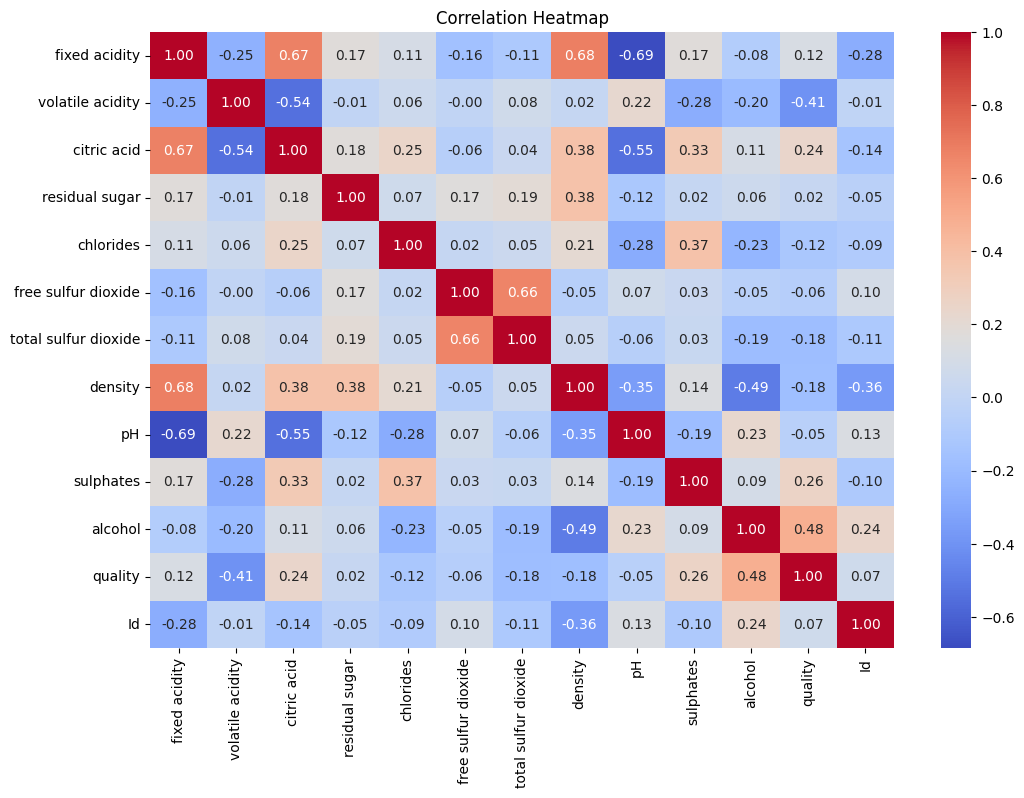

Explanation: This heatmap shows relationships between features. Alcohol is positively correlated with quality, volatile acidity is negatively correlated.

Boxplots for outlier detection:


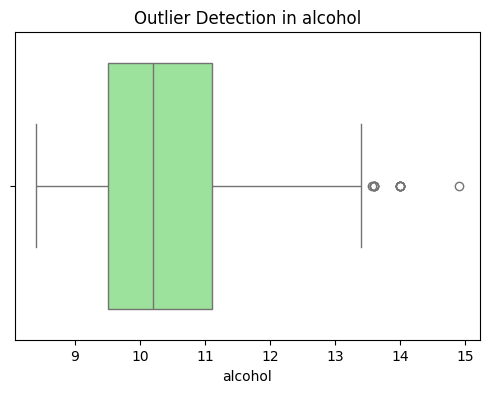

Explanation: Boxplot for alcohol shows outliers beyond the whiskers. These extreme values may affect model performance.


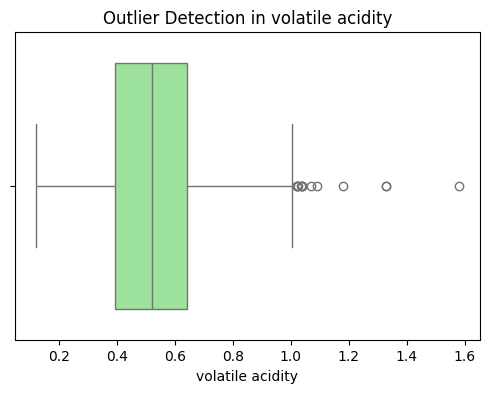

Explanation: Boxplot for volatile acidity shows outliers beyond the whiskers. These extreme values may affect model performance.


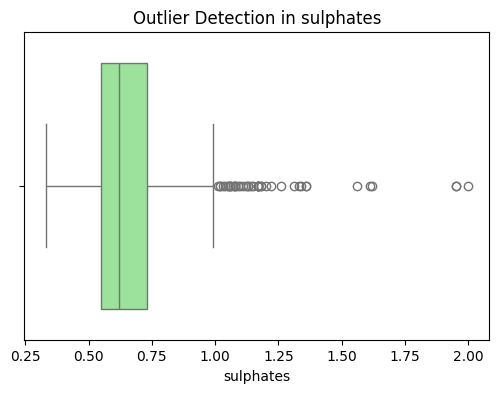

Explanation: Boxplot for sulphates shows outliers beyond the whiskers. These extreme values may affect model performance.

--- PCA Dimensionality Reduction ---
Reducing 11 chemical features into 2 principal components (PCA1, PCA2).
Scatter plot shows each wine as a point, colored by quality score.


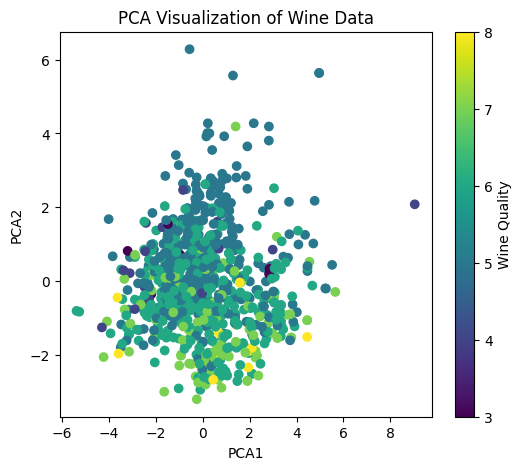


--- t-SNE Dimensionality Reduction ---
Reducing dataset into 2 nonlinear dimensions (t-SNE1, t-SNE2).
t-SNE preserves local neighborhoods better than PCA, so wines of similar quality form tighter clusters.


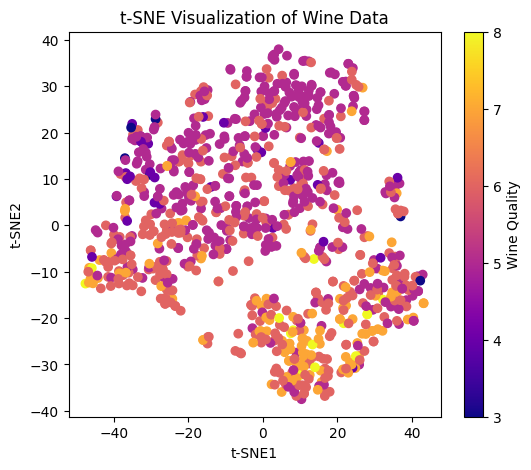


--- KMeans Clustering ---
Grouping wines into 3 clusters based on chemical properties (unsupervised).
Scatter plot shows clusters on PCA-reduced data.


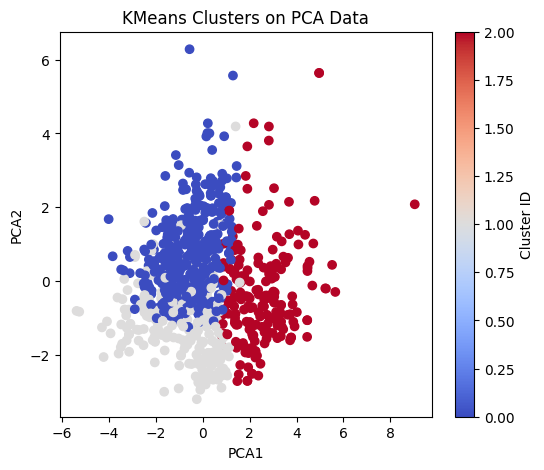


--- Random Forest Classification ---
Training Random Forest to predict wine quality...

Random Forest Accuracy: 0.6986899563318777

Classification Report:
               precision    recall  f1-score   support

           4       0.00      0.00      0.00         6
           5       0.71      0.80      0.75        96
           6       0.68      0.66      0.67        99
           7       0.72      0.69      0.71        26
           8       0.00      0.00      0.00         2

    accuracy                           0.70       229
   macro avg       0.42      0.43      0.43       229
weighted avg       0.67      0.70      0.68       229

Explanation: Random Forest predicts wine quality. Accuracy and classification report show how well the model performs across different quality scores.

Feature importance chart:


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/tmp/ipykernel_3055/3688349822.py:139: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




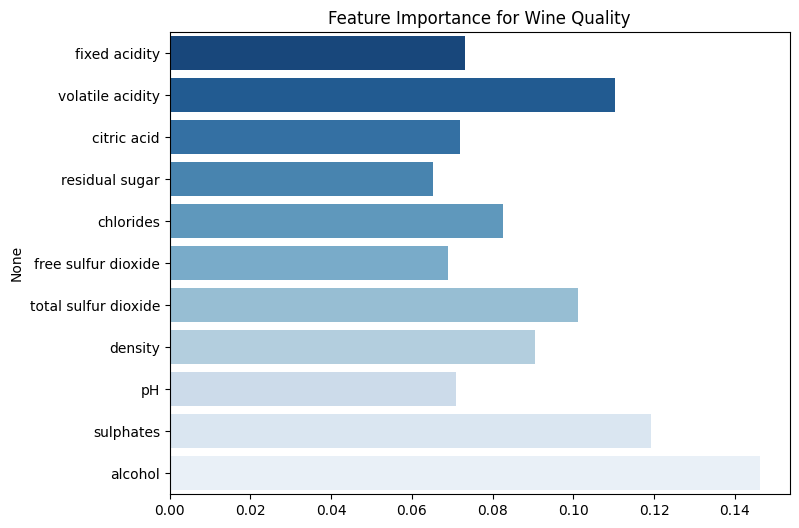

Explanation: This bar chart shows which chemical properties are most influential. Alcohol usually has the highest importance, meaning it strongly drives wine quality.

--- Interactive Plotly Visualizations ---
Creating interactive PCA, t-SNE, and KMeans plots for exploration.


Explanation: Interactive plots let you hover over points to explore wines by quality or cluster. This makes analysis more engaging and faculty can interact live.


In [ ]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import plotly.express as px

# 2. Load dataset
df = pd.read_csv("WineQT.csv")
print("Dataset Shape:", df.shape)
print(df.head())

# -------------------------------
# Extended EDA
# -------------------------------
print("\n--- EDA Section ---")
print("Checking missing values per column:")
print(df.isnull().sum())

print("\nDistribution of wine quality scores:")
plt.figure(figsize=(6,4))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribution of Wine Quality Scores")
plt.show()
print("Explanation: This bar chart shows how many wines fall into each quality score. Most wines are rated 5–6, so the dataset is imbalanced.")

print("\nHistograms for key features:")
df[['alcohol','volatile acidity','sulphates','citric acid']].hist(bins=20, figsize=(10,6), color="skyblue")
plt.suptitle("Feature Distributions")
plt.show()
print("Explanation: These histograms show how chemical properties are distributed. Alcohol is mostly between 9–11%, volatile acidity is skewed lower.")

print("\nCorrelation heatmap:")
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()
print("Explanation: This heatmap shows relationships between features. Alcohol is positively correlated with quality, volatile acidity is negatively correlated.")

print("\nBoxplots for outlier detection:")
for col in ['alcohol','volatile acidity','sulphates']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], color="lightgreen")
    plt.title(f"Outlier Detection in {col}")
    plt.show()
    print(f"Explanation: Boxplot for {col} shows outliers beyond the whiskers. These extreme values may affect model performance.")

# -------------------------------
# Preprocessing
# -------------------------------
X = df.drop(["quality","Id"], axis=1)   # features
y = df["quality"]                       # target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -------------------------------
# PCA Visualization
# -------------------------------
print("\n--- PCA Dimensionality Reduction ---")
print("Reducing 11 chemical features into 2 principal components (PCA1, PCA2).")
print("Scatter plot shows each wine as a point, colored by quality score.")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_train, cmap="viridis")
plt.title("PCA Visualization of Wine Data")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Wine Quality")
plt.show()

# -------------------------------
# t-SNE Visualization
# -------------------------------
print("\n--- t-SNE Dimensionality Reduction ---")
print("Reducing dataset into 2 nonlinear dimensions (t-SNE1, t-SNE2).")
print("t-SNE preserves local neighborhoods better than PCA, so wines of similar quality form tighter clusters.")

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_train_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_train, cmap="plasma")
plt.title("t-SNE Visualization of Wine Data")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.colorbar(label="Wine Quality")
plt.show()

# -------------------------------
# KMeans Clustering
# -------------------------------
print("\n--- KMeans Clustering ---")
print("Grouping wines into 3 clusters based on chemical properties (unsupervised).")
print("Scatter plot shows clusters on PCA-reduced data.")

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_train_scaled)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="coolwarm")
plt.title("KMeans Clusters on PCA Data")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar(label="Cluster ID")
plt.show()

# -------------------------------
# Random Forest Classification
# -------------------------------
print("\n--- Random Forest Classification ---")
print("Training Random Forest to predict wine quality...")

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

y_pred = rf.predict(X_test_scaled)

print("\nRandom Forest Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Explanation: Random Forest predicts wine quality. Accuracy and classification report show how well the model performs across different quality scores.")

print("\nFeature importance chart:")
importances = rf.feature_importances_
features = X.columns
plt.figure(figsize=(8,6))
sns.barplot(x=importances, y=features, palette="Blues_r")
plt.title("Feature Importance for Wine Quality")
plt.show()
print("Explanation: This bar chart shows which chemical properties are most influential. Alcohol usually has the highest importance, meaning it strongly drives wine quality.")

# -------------------------------
# Interactive Plotly Visualizations
# -------------------------------
print("\n--- Interactive Plotly Visualizations ---")
print("Creating interactive PCA, t-SNE, and KMeans plots for exploration.")

fig = px.scatter(x=X_pca[:,0], y=X_pca[:,1], color=y_train.astype(str),
                 labels={'x':'PCA1','y':'PCA2'}, title="Interactive PCA Plot")
fig.show()

fig2 = px.scatter(x=X_tsne[:,0], y=X_tsne[:,1], color=y_train.astype(str),
                  labels={'x':'t-SNE1','y':'t-SNE2'}, title="Interactive t-SNE Plot")
fig2.show()

fig3 = px.scatter(x=X_pca[:,0], y=X_pca[:,1], color=clusters.astype(str),
                  labels={'x':'PCA1','y':'PCA2'}, title="Interactive KMeans Clusters")
fig3.show()

print("Explanation: Interactive plots let you hover over points to explore wines by quality or cluster. This makes analysis more engaging and faculty can interact live.")
